In [2]:
import logging
import os
import json
import sys

notebook_dir = os.getcwd()
project_dir = os.path.dirname(os.path.dirname(notebook_dir))

if project_dir not in sys.path:
    sys.path.insert(0, project_dir)

print(f'Notebook dir: {notebook_dir}\nProject dir: {project_dir}.')
import force_regression.plotting.mu_plot as mu_plot
from force_regression.config.dataconfig import DataConfig
import force_regression.utils.functions as fn
from force_regression.models.linear_regression import ConventionalRegressionOnMu
from configs.constants import *
logging.getLogger().setLevel(logging.INFO)
%load_ext autoreload
%autoreload 2

Notebook dir: /Users/farahbaracat/Documents/PhD Research/Code/snn-fingerforce-decoding/notebooks/visualization
Project dir: /Users/farahbaracat/Documents/PhD Research/Code/snn-fingerforce-decoding.


In [3]:
config_path = os.path.join(project_dir, 'configs/config.json')

try:
    with open(config_path, 'r') as config_file:
        config = json.load(config_file)
        root_dir = os.path.join(project_dir, config['root_dir'])
        root_results_dir = os.path.join(project_dir, config['root_results_dir'])
        config['root_dir'] = root_dir
        config['root_results_dir'] = root_results_dir
        subject_mappings = config['subject_mappings']
        print(f'Root directory from config: {root_dir}')
except FileNotFoundError:
    print(f"Error: 'config.json' not found in {config_path}")
except json.JSONDecodeError:
    print("Error: 'config.json' is not a valid JSON file.")
except KeyError:
    print("Error: 'root_dir' not found in 'config.json'.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Root directory from config: /Volumes/big usb drive/local Thin film forearm preprocessed


# Define parameters

In [4]:
# Parameter cell for Papermill
subj = "S1"
mvc = 15
emg_type = 'intra'
sign_mvc = 1

model_type = 'linear'
overlap_in_perc = 50          # percentage overlap between the analysis windows
win_size_in_sec= 0.08         # window size in seconds
select_dir = True   # parameter to select direction of force to be used for regression. If False, both directions are used.
load_multi =[mvc]   #[mvc] the default is set to the given MVC value. Another option is a list of MVC

sweep_win_size=False   # Flag to sweep the window size. If True place results in a subfolder
segment_hold = False
load_regression_data_from_file = True
post_process= True
shuffle_fingers_seed = 10

In [5]:
config = DataConfig(root_dir=root_dir, 
                    root_results_dir = root_results_dir,
                    subject=fn.reverse_remap(subj, subject_mappings),
                    task_type="Trap", finger_type="Individual", day="Day 1", 
                    mvc=mvc, emg_type=emg_type, f_samp=10240,
                    subj_map=subject_mappings,
                    segment_hold=segment_hold, 
                    verbose=True,
                    common_only=True, 
                    images=False, 
                    time_to_cut=1,
                    load_multi=load_multi,
                    convreg_temp_data_dir='regression_data',
                    figs_dir = 'figures')

output_figures_dir = os.path.join(config.root_results_dir,
                                  config.figs_dir)

output_figures_dir


'/Volumes/big usb drive/snn-fingerforce-decoding-results/results/figures'

# Load MUs and force dataframes

In [6]:
mu_reg = ConventionalRegressionOnMu(model_type,
                                    config,
                                    emg_type,
                                    regression_data_parent_dir=config.convreg_temp_data_path,
                                    overlap_in_perc=overlap_in_perc,
                                    window_size_in_sec=win_size_in_sec,
                                    post_process=post_process,
                                    load_regression_data_from_file=load_regression_data_from_file,
                                    shuffle_fingers_seed=shuffle_fingers_seed

                                    )

In [7]:
# to load the saved mu_df and force df
mu_reg.create_mu_regression_df()

INFO:root:little duration: 27.93759765625


little  force_avg:(697, 5) 


INFO:root:thumb duration: 27.93759765625


thumb  force_avg:(697, 5) 


INFO:root:index duration: 27.93759765625


...

little  force_avg:(697, 5) 


INFO:root:middle duration: 27.93759765625


middle  force_avg:(697, 5) 


INFO:root:thumb duration: 27.93759765625
INFO:root:Rep 2 (3485, 244) all repetitions: (6970, 244)


thumb  force_avg:(697, 5) 


In [8]:
mu_reg.data_config.force_cols_list

['force_thumb', 'force_index', 'force_middle', 'force_ring', 'force_little']

In [9]:
force_df = mu_reg.force_df
force_df[force_df[FING_NAME_COL]=='thumb']
temp_df = force_df[force_df[FING_NAME_COL]=='thumb']
temp_df[(temp_df[FING_DIR] == 'flex') & (temp_df[REP_ID]==0)]

,force_thumb,force_index,force_middle,force_ring,force_little,time,rep_id,fing_dir,mvc_lvl,fing_name
0,0.033892,-0.003571,-0.111713,-0.002811,0.000341,0.000000,0,flex,15,thumb
1,0.033892,-0.084735,-0.019235,-0.002811,0.000341,0.000098,0,flex,15,thumb
2,0.033892,-0.003571,-0.019235,0.097576,0.000341,0.000195,0,flex,15,thumb
3,0.033892,-0.003571,-0.019235,0.097576,0.085586,0.000293,0,flex,15,thumb
4,0.033892,-0.003571,-0.111713,-0.002811,0.085586,0.000391,0,flex,15,thumb
...,...,...,...,...,...,...,...,...,...,...
286076,0.914207,-0.328226,-0.296668,0.197963,0.682298,27.937109,0,flex,15,thumb
286077,0.914207,-0.328226,-0.296668,0.197963,0.682298,27.937207,0,flex,15,thumb
286078,0.914207,-0.409390,-0.296668,0.197963,0.682298,27.937305,0,flex,15,thumb
286079,0.914207,-0.328226,-0.296668,0.197963,0.682298,27.937402,0,flex,15,thumb


INFO:root:Finger thumb rep 2: plotting 7 MUs: sptimes:321 first tensor([5.0711, 5.2348, 5.3675, 5.4867, 5.5775, 5.6724, 5.7664, 5.8432, 5.9359,
        6.0110])
INFO:root:Finger index rep 2: plotting 8 MUs: sptimes:205 first tensor([5.8146, 6.2288, 6.3310, 6.4639, 6.6884, 6.8457, 7.0551, 9.4780, 9.6170,
        9.7096])
INFO:root:Finger middle rep 2: plotting 37 MUs: sptimes:239 first tensor([3.0706, 3.4582, 3.5942, 3.8856, 3.9518, 4.0848, 4.1966, 4.2764, 4.3667,
        4.4597])
INFO:root:Finger ring rep 2: plotting 28 MUs: sptimes:146 first tensor([3.2894, 3.3784, 3.5196, 3.6727, 3.7571, 3.8503, 3.9347, 4.0719, 4.1400,
        4.2309])
INFO:root:Finger little rep 2: plotting 41 MUs: sptimes:371 first tensor([3.1461, 7.7370, 7.8087, 7.9671, 8.0157, 8.0404, 8.0630, 8.0905, 8.1083,
        8.1495])


Saving figure to /Volumes/big usb drive/snn-fingerforce-decoding-results/results/figures/S1/mu_analysis/mu_force_plot_rep_2_allforces_True_common_S1_Trap_0_15_1_1_3_20.pdf
Data successfully saved to /Users/farahbaracat/Documents/PhD Research/Code/snn-fingerforce-decoding/SourceDataMain.xlsx in sheet 'Fig1c_decomposition'.
Data successfully saved to /Users/farahbaracat/Documents/PhD Research/Code/snn-fingerforce-decoding/SourceDataMain.xlsx in sheet 'Fig1c_decomposition_force_rep2'.


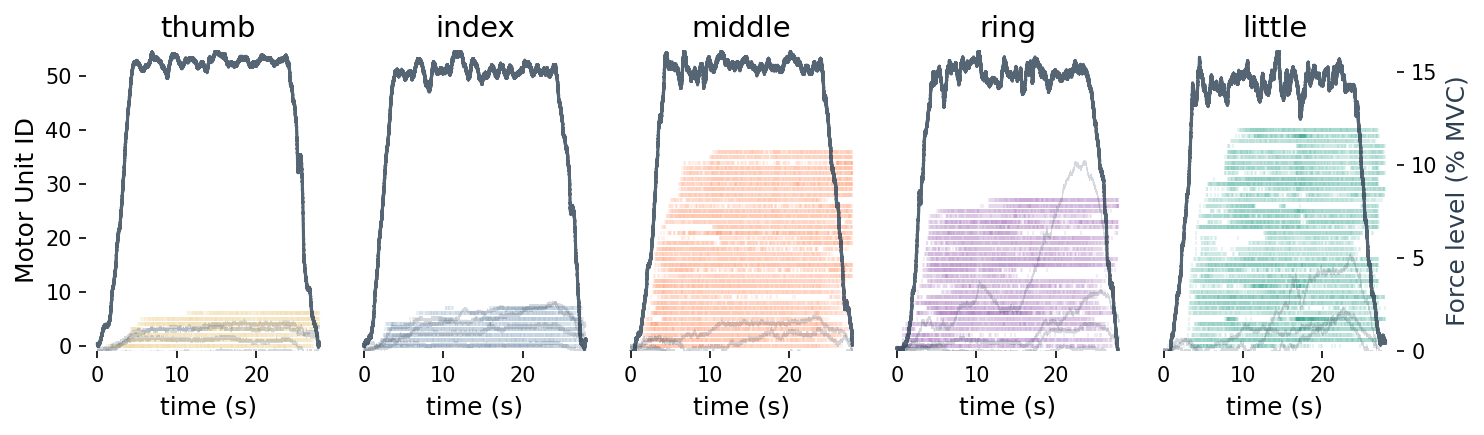

In [23]:
source_data_main_file = 'SourceDataMain.xlsx'
source_data_path = os.path.join(project_dir, source_data_main_file)
for plot_dir in [['flex']]:
    mu_plot.raster_plot_sep_rep_inset(mu_reg.mu_df_sorted, config, mu_reg.force_df, 
                                    plot_direction=plot_dir,
                                    plot_common_only=True, 
                                    save_fig=True,
                                    rep_list=[2],
                                    max_ylim=55,  #flex: 55, ext:rep1:80
                                    plot_all_forces=True,
                                    same_mus_color_per_task=False,
                                    output_figures_dir=output_figures_dir,
                                    source_data_path=source_data_path,
                                    sheet_name=f'Fig1c_decomposition'
                                    )